In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import platform

In [2]:
#그래프 시각화에서 한글 깨짐 방지 
if platform.system() == 'Darwin':
    #MAC 사용자
    plt.rc('font', family='AppleGothic')
else:
    plt.rc('font', family='Malgun Gothic')
#마이너스 깨짐 방지
plt.rcParams['axes.unicode_minus']=False

In [4]:
#신용카드 사기 거래 데이터셋 로드
df=pd.read_csv('../../data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [6]:
#결측치의 개수를 확인
df.isna().sum().sum()

np.int64(0)

In [7]:
df[['Time','Amount']].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


In [8]:
# Time 컬럼의 데이터의 의미는 'Sec' --> 'Hour'
# 24시간 체계로 변환 
df['Hour'] = (df['Time'] // 3600) % 24

In [9]:
df['Hour'].describe()

count    284807.000000
mean         14.046470
std           5.835854
min           0.000000
25%          10.000000
50%          15.000000
75%          19.000000
max          23.000000
Name: Hour, dtype: float64

In [10]:
# 정상거래와 이상거래의 빈도수 체크 
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

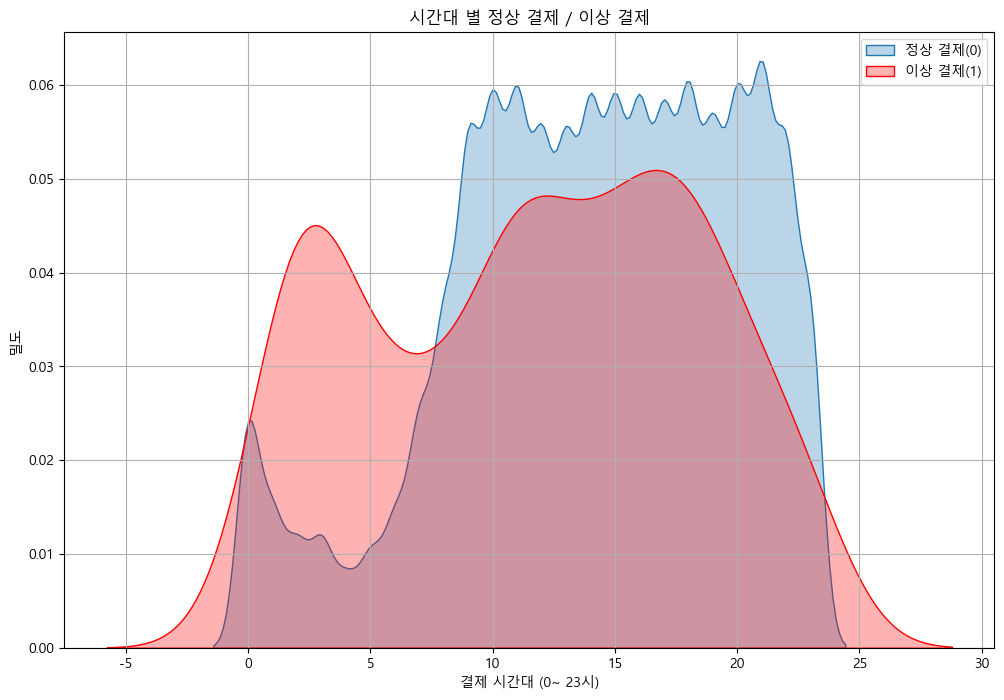

In [13]:
# 밀도 그래프 시각화 
plt.figure(figsize=(12, 8))

sns.kdeplot( df.loc[ df['Class'] == 0, 'Hour' ], label = '정상 결제(0)', fill=True, alpha=0.3 )

sns.kdeplot( df.loc[ df['Class'] == 1, 'Hour' ], label = '이상 결제(1)', fill=True, alpha=0.3, color='red' )

plt.title('시간대 별 정상 결제 / 이상 결제')
plt.xlabel('결제 시간대 (0~ 23시)')
plt.ylabel('밀도')
plt.legend()
plt.grid(True)
plt.show()

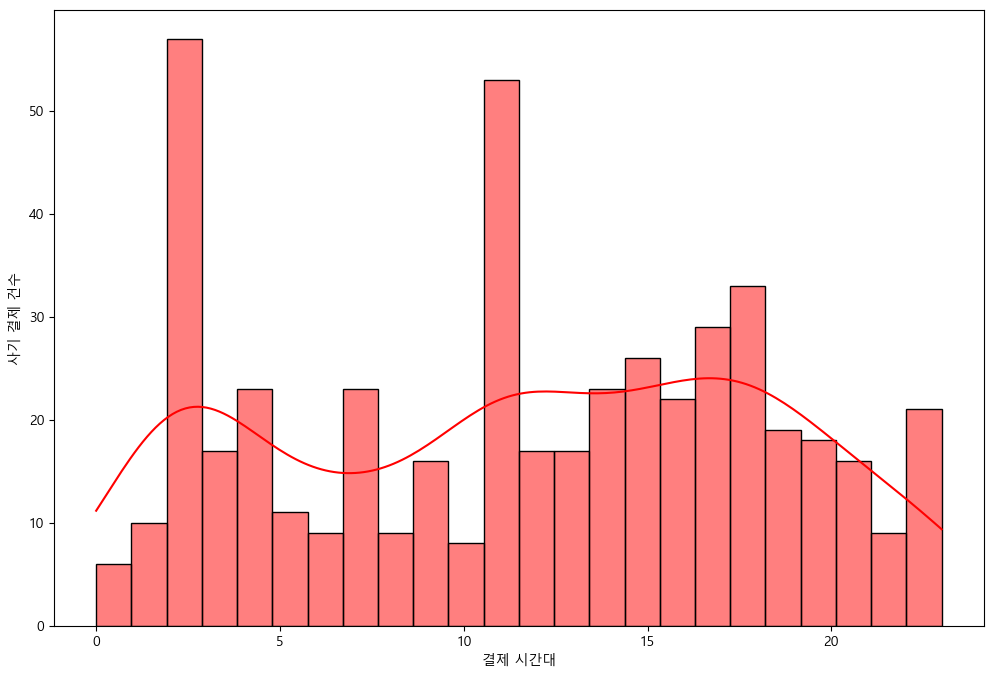

In [14]:
# 절대량 시각화 

plt.figure(figsize=(12, 8))

sns.histplot( df.loc[ df['Class'] == 1, ], x = 'Hour', bins = 24, color='red', kde = True )

plt.xlabel('결제 시간대')
plt.ylabel('사기 결제 건수')
plt.show()

In [15]:
# 결제 시간대 별 전체 결제 건수 대비 사기 결제 건수의 비율
# 0시  ->   사기거래 건수(70) / 전체 거래 건수(100) * 100 --> 70%
# 정상 거래 (0)  / 사기 거래 (1) -> 모든 데이터를 더하면? -> 사기 거래의 건수
# 전체 데이터의 개수와 나눠준다? -> 평균 (mean)
group_df = df.groupby('Hour')['Class'].mean() * 100
group_df

Hour
0.0     0.077973
1.0     0.236967
2.0     1.712740
3.0     0.486827
4.0     1.041195
5.0     0.367893
6.0     0.219459
7.0     0.317548
8.0     0.087583
9.0     0.101023
10.0    0.048199
11.0    0.314428
12.0    0.110246
13.0    0.110641
14.0    0.138805
15.0    0.157949
16.0    0.133714
17.0    0.179389
18.0    0.193673
19.0    0.121414
20.0    0.107424
21.0    0.090380
22.0    0.058286
23.0    0.191991
Name: Class, dtype: float64

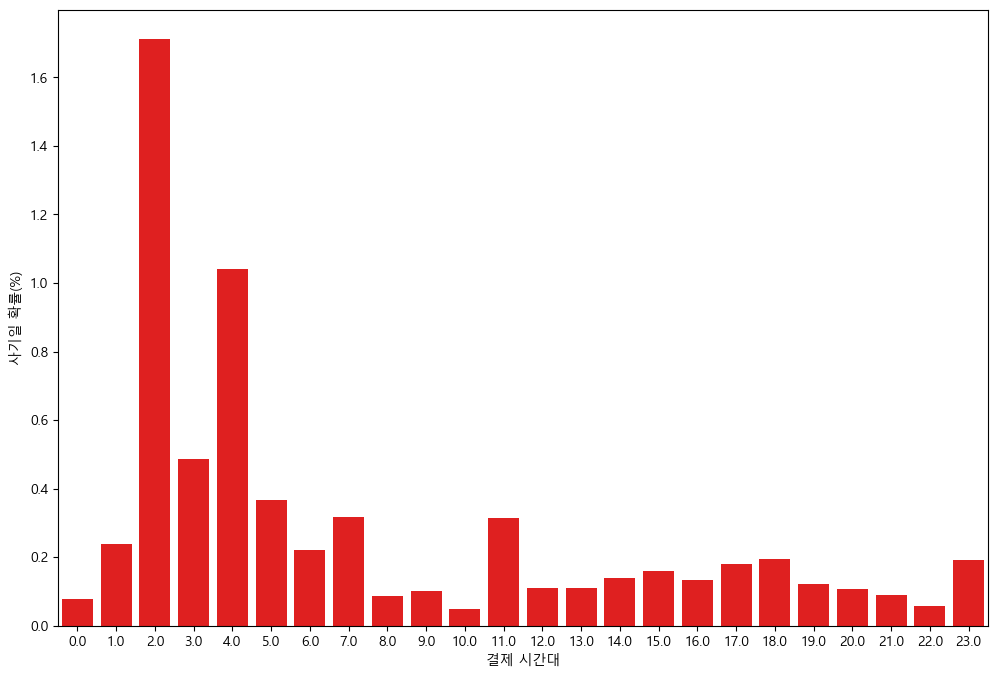

In [16]:
plt.figure(figsize=(12, 8))
sns.barplot(x = group_df.index, y = group_df.values, color = 'red')
plt.xlabel('결제 시간대')
plt.ylabel('사기일 확률(%)')
plt.show()

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler

In [18]:
# 시간 데이터와 class 는 학습 데이터에서 제외 
x = df.drop(['Time', 'Class'], axis=1)
y = df['Class']

In [19]:
scaler = StandardScaler()
x['Amount'] = scaler.fit_transform(x[['Amount']])

In [20]:
# 학습 / 검증 데이터로 데이터 분할 
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [21]:
print(f"Train Data에서 정상 거래 건수 : {sum(y_train == 0)} 사기 거래 건수 : {sum(y_train == 1)}")

Train Data에서 정상 거래 건수 : 227451 사기 거래 건수 : 394


In [22]:
# 일반 모델 -> 기본값을 사용
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)
pred1 = model1.predict(X_test)

In [23]:
# 데이터의 불균형 문제를 해결하기 위해 모델에서 class_weight 매개변수를 수정 
model2 = LogisticRegression(max_iter=1000, class_weight='balanced')
model2.fit(X_train, y_train)
pred2 = model2.predict(X_test)

In [24]:
print(f"일반 모델")
print(classification_report(y_test, pred1))
print(f"밸런스 모델")
print(classification_report(y_test, pred2))

일반 모델
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.92      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962

밸런스 모델
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.91      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [25]:
#사기 거래 데이터에서 SMOTE를 이용하여 소수의 데이터를 늘려준다. -> 1번 모델을 이용해서 학습, 예측
from imblearn.over_sampling import SMOTE

In [26]:
smote=SMOTE(random_state=42)
X_train_sm,y_train_sm=smote.fit_resample(X_train,y_train)

In [27]:
print(f'SMOTE 후 정상 거래 개수 : {sum(y_train_sm == 0)}, 사기 거래 건수 : {sum(y_train_sm == 1)}')

SMOTE 후 정상 거래 개수 : 227451, 사기 거래 건수 : 227451


In [28]:
# SMOTE를 이용하여 데이터의 비율을 맞추고 모델1에 학습 및 예측 -> 검증 
model1.fit(X_train_sm, y_train_sm)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [29]:
pred3=model1.predict(X_test)
print('SMOTE 후 일반 모델')
print(classification_report(y_test,pred3))

SMOTE 후 일반 모델
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.05      0.91      0.10        98

    accuracy                           0.97     56962
   macro avg       0.53      0.94      0.54     56962
weighted avg       1.00      0.97      0.98     56962



In [30]:
#sHAP value 확인
# !pip install shap

In [31]:
import shap

c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [32]:
# SHAP 설명기 -> 선형 모델용 LinearExplainer
explainer = shap.LinearExplainer(model2, X_train)

# 분석할 타켓 데이터를 선정 -> 사기 결제 데이터중 첫번째 데이터 선택 
target_data = X_test[y_test == 1].iloc[[0]]
target_data

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Hour
77348,-1.271244,2.462675,-2.851395,2.32448,-1.372245,-0.948196,-3.065234,1.166927,-2.268771,-4.881143,...,0.652941,0.081931,-0.221348,-0.523582,0.224228,0.756335,0.6328,0.250187,-0.353189,15.0


In [33]:
#SHAP value 계산
shap_value= explainer.shap_values(target_data)
shap_value

array([[-0.92932411,  1.70814072, -1.32317062,  2.54821271, -1.40792603,
         0.63353057,  2.3055413 , -0.6734873 ,  0.9606591 ,  6.46187758,
         1.63050995,  6.31152375, -0.2775829 ,  9.78212169, -0.07815744,
         5.85768354,  7.62368856,  1.1080978 ,  0.48674729, -0.97774072,
         0.04269484,  0.08955792, -0.18073547,  0.02669786,  0.01000886,
        -0.24302004, -0.29800303,  0.2597708 , -0.80496232,  0.03454766]])

c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\shap\plots\_waterfall.py:638: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
C:\Users\user\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) Malgun Gothic.
  fig.canvas.print_figure(bytes_io, **kw)


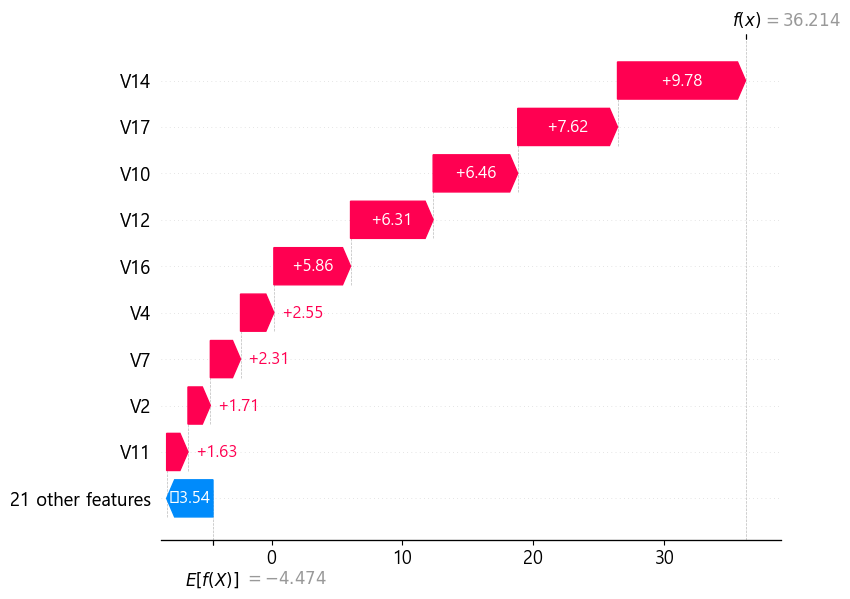

In [35]:
# 폭포수 챠트 
shap.plots._waterfall.waterfall_legacy(explainer.expected_value, shap_value[0], feature_names= x.columns)

In [36]:
#LIME라이브러리 설치
# !pip install lime

In [42]:
import lime.lime_tabular as lime

# lime 설명기 초기화(객체 생성)
explainer_lime = lime.LimeTabularExplainer(
    training_data= X_train.values, 
    feature_names= x.columns, 
    class_names = ['정상결제(0)', '사기결제(1)'], 
    mode = 'classification', 
    random_state=42
)

In [38]:
#분석할 타겟 데이터를 지정
target_data=X_test[y_test == 1].iloc[1]
target_data

V1       -13.192671
V2        12.785971
V3        -9.906650
V4         3.320337
V5        -4.801176
V6         5.760059
V7       -18.750889
V8       -37.353443
V9        -0.391540
V10       -5.052502
V11        4.406806
V12       -4.610756
V13       -1.909488
V14       -9.072711
V15       -0.226074
V16       -6.211557
V17       -6.248145
V18       -3.149247
V19        0.051576
V20       -3.493050
V21       27.202839
V22       -8.887017
V23        5.303607
V24       -0.639435
V25        0.263203
V26       -0.108877
V27        1.269566
V28        0.939407
Amount    -0.349231
Hour      18.000000
Name: 102442, dtype: float64

In [46]:
# LIME 설명을 할수 있는 데이터를 출력 
exp = explainer_lime.explain_instance(
    data_row= target_data.values, 
    predict_fn=model2.predict_proba, 
    num_features=5
)

c:\Users\user\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


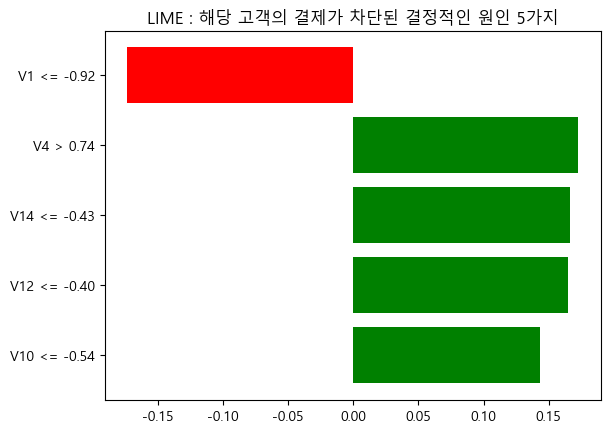

In [47]:
exp.as_pyplot_figure()
plt.title("LIME : 해당 고객의 결제가 차단된 결정적인 원인 5가지")
plt.show()

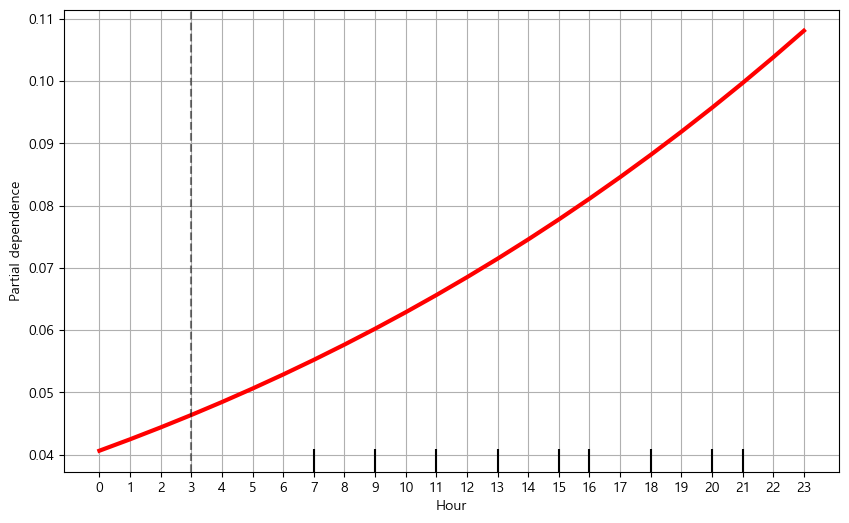

In [49]:
# PDP -> 특정 컬럼이 변화할때 예측 값에 대해 영향력을 확인 
from sklearn.inspection import PartialDependenceDisplay

# 결제 시간대가 사기 거래 판정 확률에 미치는 영향 

fig, ax = plt.subplots(figsize = (10, 6))

# PDP 그래프 생성 
pdp_display = PartialDependenceDisplay.from_estimator(
    estimator= model2, 
    X = X_train, 
    features = ['Hour'], 
    kind = 'average', 
    ax = ax, 
    line_kw={'color' : 'red', 'linewidth' : 3}
)

# 보조선 추가 
plt.axvline( x = 3, color='black', linestyle='--', alpha = 0.5 )
plt.xticks(range(0, 24))
plt.grid()
plt.show()

In [50]:
from sklearn.ensemble import RandomForestClassifier

In [51]:
rf=RandomForestClassifier(
    n_estimators=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced_subsample'
)
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",10
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

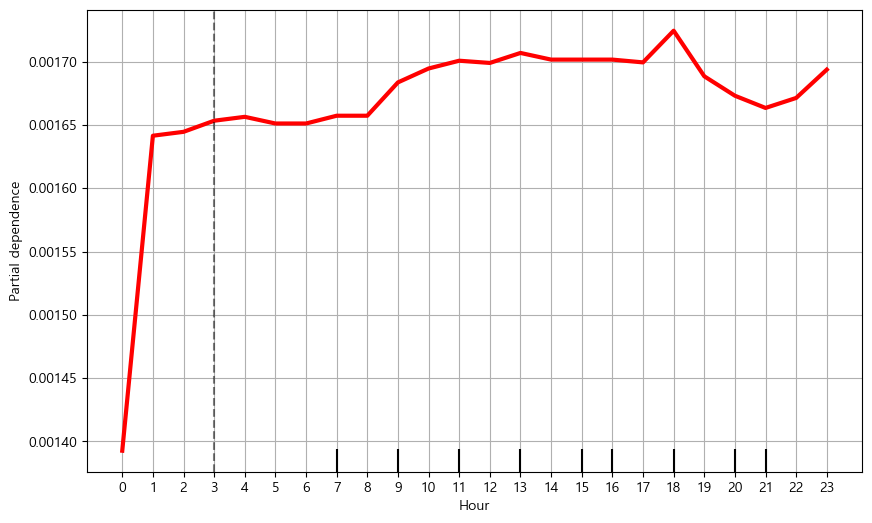

In [52]:
fig, ax = plt.subplots(figsize = (10, 6))

# PDP 그래프 생성 
pdp_display = PartialDependenceDisplay.from_estimator(
    estimator= rf, 
    X = X_train, 
    features = ['Hour'], 
    kind = 'average', 
    ax = ax, 
    line_kw={'color' : 'red', 'linewidth' : 3}
)

# 보조선 추가 
plt.axvline( x = 3, color='black', linestyle='--', alpha = 0.5 )
plt.xticks(range(0, 24))
plt.grid()
plt.show()